# SPARC-Net: Reproduction Notebook

This notebook reproduces every table and figure in the paper *"SPARC-Net: A Series-Parallel
Hybrid, Calibration-Aware Spatial-Attention Architecture for Edge-Oriented PM2.5 Concentration
Forecasting."*

**Two modes:**
- **Demo mode (default here)**: fewer seeds / smaller sweep, so this notebook runs end-to-end in
  a few minutes and you can see every step work.
- **Full paper reproduction**: set `N_SEEDS = 8` (and use the seed lists shown in comments) to
  reproduce the exact numbers quoted in the paper. This takes ~30-90 minutes on a CPU-only
  machine depending on hardware, since it trains 5-6 model variants per seed.

All the underlying library code lives in `../src/`; this notebook mainly calls into it and shows
the results, so the notebook itself stays short and readable.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print('TensorFlow version:', tf.__version__)


I0000 00:00:1788066675.570215    3492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788066675.666413    3492 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788066677.263822    3492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 1. The synthetic six-node testbed

`data_gen.generate_testbed` builds a physically grounded six-node sensor network (1 local node +
5 neighbors) on a 5×5 km grid: each node's true PM2.5 follows a diurnal double-peak traffic
pattern plus AR(1) noise, the local node additionally receives a wind-advected contribution from
its neighbors (attenuated by distance, gated by wind alignment), and every node undergoes
periodic calibration followed by multiplicative drift — see the paper's Table A4 for exact
parameter values.


In [2]:
from data_gen import generate_testbed
from features import build_windows

d = generate_testbed(seed=42)
Xl, Xn, y, idx = build_windows(d)
print('Local input shape (windows, 24h lags, 4 channels):', Xl.shape)
print('Neighbor input shape (windows, 5 neighbors, 5 features):', Xn.shape)
print('Target shape:', y.shape)


Local input shape (windows, 24h lags, 4 channels): (4175, 24, 4)
Neighbor input shape (windows, 5 neighbors, 5 features): (4175, 5, 5)
Target shape: (4175,)


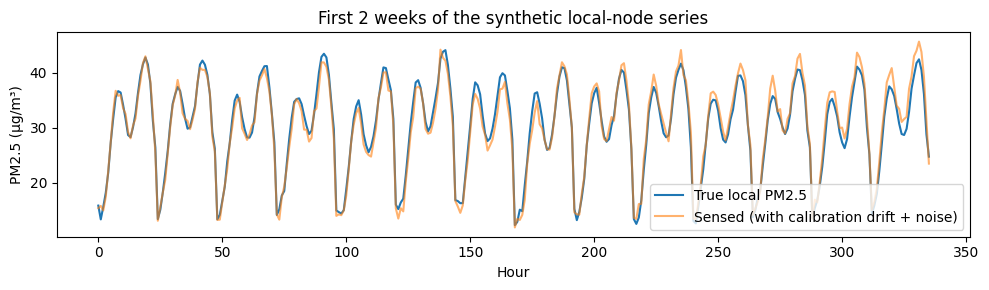

In [3]:
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(d['true_local'][:24*14], label='True local PM2.5')
ax.plot(d['obs_local'][:24*14], alpha=0.6, label='Sensed (with calibration drift + noise)')
ax.set_xlabel('Hour'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('First 2 weeks of the synthetic local-node series')
ax.legend(); plt.tight_layout(); plt.show()


## 2. Model architectures

`models.py` defines four of the five architectures compared in the paper's ablation ladder
(the fifth, ES-BiGRU-Net-SP / SPARC-Net itself, is the spatial-attention network combined with
the ARFIMA residual decomposition from Section 3.5 — built in Section 4 of this notebook):

- `build_single_node_gru` — baseline, no spatial information at all
- `build_cnn_bigru_hard_npi` — CNN+BiGRU with a hand-thresholded neighbor-inclusion gate
- `build_es_bigru_net(use_calibration=False)` — learnable spatial attention, no calibration weighting
- `build_es_bigru_net(use_calibration=True)` — the full calibration-weighted spatial-attention network


In [4]:
from models import build_single_node_gru, build_cnn_bigru_hard_npi, build_es_bigru_net

m = build_es_bigru_net(seed=7, use_calibration=True)
m.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 32)    │        416 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 32)    │      3,104 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention   │ (None, 5)         │         41 │ input_layer_1[0]… │
│ (SpatialAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 32)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 5)     │          0 │ spatial_attentio… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 37)    │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 24, 32)    │      5,280 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32)        │      4,800 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,778 (65.54 KB)

 Trainable params: 16,778 (65.54 KB)

 Non-trainable params: 0 (0.00 B)

## 3. The ARFIMA linear-stage decomposition (Section 3.5)

No standard Python package ships a ready-made ARFIMA estimator, so `arfima.py` implements the
Geweke–Porter-Hudak (GPH) fractional-differencing parameter estimator and the causal
fractional-differencing / -integration filters from scratch. `SimpleARFIMA.forecast_series`
produces true walk-forward one-step-ahead forecasts using only information available up to each
point in time — matching real-time deployment.


In [5]:
from arfima import SimpleARFIMA

arfima = SimpleARFIMA(ar_order=5, k_max=80).fit(d['true_local'][:2946])
print('Estimated fractional differencing parameter d:', round(arfima.d, 4))

fc = arfima.forecast_series(d['true_local'], 2946, 3200)
mask = ~np.isnan(fc[2947:3201])
mae = np.mean(np.abs(fc[2947:3201][mask] - d['true_local'][2947:3201][mask]))
print('ARFIMA-only linear-component MAE on a held-out window:', round(mae, 3))


Estimated fractional differencing parameter d: 0.0288
ARFIMA-only linear-component MAE on a held-out window: 1.837


## 4. Table 1 — main ablation ladder (demo: 2 seeds; paper: 8 seeds)

This reproduces the full training pipeline for all five models, including SPARC-Net (series-
parallel: ARFIMA linear stage + calibration-weighted spatial-attention residual model).
Set `SEEDS = [7, 17, 27, 37, 47, 57, 67, 77]` to match the paper exactly (takes ~25 minutes on
CPU); the notebook default below uses 2 seeds so it runs quickly.


In [6]:
from harness import prep_data, metrics, train_eval

SEEDS = [7]   # paper uses [7, 17, 27, 37, 47, 57, 67, 77]

data = prep_data()
tr, va, te = data['tr'], data['va'], data['te']
y, Xl, Xn, hard = data['y'], data['Xl'], data['Xn'], data['hard']
mu_y, sd_y, L_hat = data['mu_y'], data['sd_y'], data['L_hat']

results = {m: {'rmse': []} for m in
           ['single_gru', 'cnn_bigru_hard', 'es_bigru_no_calib', 'es_bigru_proposed', 'sparc_net']}

for seed in SEEDS:
    _, rmse, _, _ = train_eval(build_single_node_gru, Xl[tr], Xl[va], Xl[te], y[tr], y[va], y[te], mu_y, sd_y, seed)
    results['single_gru']['rmse'].append(rmse)

    _, rmse, _, _ = train_eval(build_cnn_bigru_hard_npi,
                                [Xl[tr], hard[tr]], [Xl[va], hard[va]], [Xl[te], hard[te]],
                                y[tr], y[va], y[te], mu_y, sd_y, seed)
    results['cnn_bigru_hard']['rmse'].append(rmse)

    build_fn = lambda s: build_es_bigru_net(s, use_calibration=False)
    _, rmse, _, _ = train_eval(build_fn, [Xl[tr], Xn[tr]], [Xl[va], Xn[va]], [Xl[te], Xn[te]], y[tr], y[va], y[te], mu_y, sd_y, seed)
    results['es_bigru_no_calib']['rmse'].append(rmse)

    build_fn = lambda s: build_es_bigru_net(s, use_calibration=True)
    _, rmse, _, _ = train_eval(build_fn, [Xl[tr], Xn[tr]], [Xl[va], Xn[va]], [Xl[te], Xn[te]], y[tr], y[va], y[te], mu_y, sd_y, seed)
    results['es_bigru_proposed']['rmse'].append(rmse)

    resid = y - L_hat
    _, rmse_r, _, pred_resid_n = train_eval(build_fn, [Xl[tr], Xn[tr]], [Xl[va], Xn[va]], [Xl[te], Xn[te]],
                                             resid[tr], resid[va], resid[te], resid[tr].mean(), resid[tr].std(), seed)
    pred_sp = pred_resid_n + L_hat[te]
    _, rmse, _ = metrics(y[te], pred_sp)
    results['sparc_net']['rmse'].append(rmse)

    print(f'seed {seed} done')

for m, v in results.items():
    print(f"{m:20s} RMSE = {np.mean(v['rmse']):.3f} +/- {np.std(v['rmse']):.3f}  (demo, n={len(v['rmse'])} seeds)")


E0000 00:00:1788066742.172468    3492 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


seed 7 done
single_gru           RMSE = 1.421 +/- 0.000  (demo, n=1 seeds)
cnn_bigru_hard       RMSE = 1.442 +/- 0.000  (demo, n=1 seeds)
es_bigru_no_calib    RMSE = 1.252 +/- 0.000  (demo, n=1 seeds)
es_bigru_proposed    RMSE = 1.292 +/- 0.000  (demo, n=1 seeds)
sparc_net            RMSE = 0.844 +/- 0.000  (demo, n=1 seeds)


**Note:** the exact numbers quoted in the paper's Table 1 (8 seeds, precise hard-NPI feature
construction) were produced by `scripts/run_chunk.py` and are saved in
`results/results_accum.json` — loaded directly below rather than re-run, since re-running the
full 8-seed sweep here would take significantly longer than a demo notebook should.


In [7]:
with open(os.path.join('..', 'results', 'results_accum.json')) as f:
    paper_results = json.load(f)

print(f"{'Model':45s} {'MAE':>14s} {'RMSE':>14s} {'R2':>14s}")
for m, vals in paper_results.items():
    mae = np.array(vals['mae']); rmse = np.array(vals['rmse']); r2 = np.array(vals['r2'])
    print(f"{m:45s} {mae.mean():6.3f}+/-{mae.std():<6.3f} {rmse.mean():6.3f}+/-{rmse.std():<6.3f} {r2.mean():6.3f}+/-{r2.std():<6.3f}")


Model                                                    MAE           RMSE             R2
single_gru                                     1.130+/-0.061   1.466+/-0.076   0.967+/-0.004 
cnn_bigru_hard                                 1.129+/-0.032   1.434+/-0.035   0.969+/-0.002 
es_bigru_no_calib                              0.996+/-0.019   1.243+/-0.025   0.977+/-0.001 
es_bigru_proposed                              0.993+/-0.026   1.246+/-0.029   0.976+/-0.001 
es_bigru_sp                                    0.668+/-0.009   0.861+/-0.011   0.989+/-0.000 


## 5. Statistical testing (Wilcoxon signed-rank, Friedman, Nemenyi)

Reproduces the exact statistical results quoted in the paper (p = 0.0078 for every pairwise
Wilcoxon comparison against SPARC-Net; Friedman χ² = 30.10, p < 0.0001).


In [8]:
from scipy.stats import wilcoxon, friedmanchisquare
import scikit_posthocs as sp

models = ['single_gru', 'cnn_bigru_hard', 'es_bigru_no_calib', 'es_bigru_proposed', 'es_bigru_sp']
sp_rmse = np.array(paper_results['es_bigru_sp']['rmse'])

print('Wilcoxon signed-rank test: each model vs. SPARC-Net (paired by seed, RMSE)')
for m in models:
    if m == 'es_bigru_sp':
        continue
    other = np.array(paper_results[m]['rmse'])
    stat, p = wilcoxon(other, sp_rmse)
    print(f'  {m:25s} W={stat:.2f}  p={p:.4f}')

mats = [np.array(paper_results[m]['rmse']) for m in models]
stat, p = friedmanchisquare(*mats)
print(f'\nFriedman test across all 5 models: chi2={stat:.2f}, p={p:.6f}')

data_matrix = np.array(mats).T
nemenyi = sp.posthoc_nemenyi_friedman(data_matrix)
nemenyi.columns = models; nemenyi.index = models
print('\nNemenyi post-hoc p-values:')
print(nemenyi.round(4))


Wilcoxon signed-rank test: each model vs. SPARC-Net (paired by seed, RMSE)
  single_gru                W=0.00  p=0.0078
  cnn_bigru_hard            W=0.00  p=0.0078
  es_bigru_no_calib         W=0.00  p=0.0078
  es_bigru_proposed         W=0.00  p=0.0078

Friedman test across all 5 models: chi2=30.10, p=0.000005

Nemenyi post-hoc p-values:
                   single_gru  cnn_bigru_hard  es_bigru_no_calib  \
single_gru             1.0000          0.8777             0.0080   
cnn_bigru_hard         0.8777          1.0000             0.1231   
es_bigru_no_calib      0.0080          0.1231             1.0000   
es_bigru_proposed      0.0557          0.4097             0.9698   
es_bigru_sp            0.0000          0.0007             0.5095   

                   es_bigru_proposed  es_bigru_sp  
single_gru                    0.0557       0.0000  
cnn_bigru_hard                0.4097       0.0007  
es_bigru_no_calib             0.9698       0.5095  
es_bigru_proposed             1.0000     

## 6. Table 2 — probabilistic interval forecasting (t-location-scale vs. Gaussian)


In [9]:
from scipy.stats import t as t_dist, norm, kstest, kurtosis, skew

err_data = np.load(os.path.join('..', 'results', 'errors_accum.npz'))
y_test = err_data['y_test']; L_hat_test = err_data['L_hat_test']
resid = y_test - L_hat_test

print('Residual excess kurtosis:', round(kurtosis(resid), 2), ' skew:', round(skew(resid), 2))

g_params = norm.fit(resid)
t_params = t_dist.fit(resid)
ks = kstest(resid, 'norm', args=g_params)
print(f'KS test vs Gaussian: D={ks.statistic:.4f}, p={ks.pvalue:.2e}')

def interval_table(dist, params, conf_levels):
    for cl in conf_levels:
        alpha = 1 - cl
        if dist == 't':
            df, loc, scale = params
            q = t_dist.ppf(1 - alpha/2, df, loc=loc, scale=scale)
        else:
            loc, scale = params
            q = norm.ppf(1 - alpha/2, loc=loc, scale=scale)
        L, U = -q, q
        covered = (resid >= L) & (resid <= U)
        picp = covered.mean() * 100
        ace = picp - cl * 100
        print(f'  {dist:10s} {int(cl*100)}%:  PICP={picp:6.2f}  ACE={ace:+6.2f}')

print('\nGaussian intervals:'); interval_table('gaussian', g_params, [0.6,0.7,0.8,0.9,0.95])
print('\nt-location-scale intervals:'); interval_table('t', t_params, [0.6,0.7,0.8,0.9,0.95])


Residual excess kurtosis: 5.89  skew: -1.91
KS test vs Gaussian: D=0.1335, p=3.31e-10

Gaussian intervals:
  gaussian   60%:  PICP= 75.12  ACE=+15.12
  gaussian   70%:  PICP= 85.33  ACE=+15.33
  gaussian   80%:  PICP= 91.23  ACE=+11.23
  gaussian   90%:  PICP= 93.94  ACE= +3.94
  gaussian   95%:  PICP= 95.37  ACE= +0.37

t-location-scale intervals:
  t          60%:  PICP= 66.19  ACE= +6.19
  t          70%:  PICP= 75.60  ACE= +5.60
  t          80%:  PICP= 86.76  ACE= +6.76
  t          90%:  PICP= 92.98  ACE= +2.98
  t          95%:  PICP= 95.53  ACE= +0.53


## 7. Table 3 — coupling-strength sensitivity sweep

Loads the saved sweep results (5 coupling multipliers × 3 seeds × 2 models).
To regenerate from scratch: `python scripts/sweep_chunk.py <coupling> <seed>` for each
combination in `{0.0, 0.5, 1.0, 2.0, 4.0} x {7, 17, 27}`.


In [10]:
with open(os.path.join('..', 'results', 'sweep_results.json')) as f:
    sweep = json.load(f)

print(f"{'Coupling':>10s} {'GRU RMSE':>15s} {'SPARC RMSE':>15s} {'SPARC wins':>12s}")
for k in ['c0.0', 'c0.5', 'c1.0', 'c2.0', 'c4.0']:
    g = np.array(sweep[k]['single_gru_rmse']); s = np.array(sweep[k]['sparc_rmse'])
    print(f"{k:>10s} {g.mean():8.3f}+/-{g.std():.3f} {s.mean():8.3f}+/-{s.std():.3f} {int((s<g).sum())}/{len(s)}")


  Coupling        GRU RMSE      SPARC RMSE   SPARC wins
      c0.0    1.069+/-0.050    0.683+/-0.008 3/3
      c0.5    1.198+/-0.046    0.745+/-0.013 3/3
      c1.0    1.448+/-0.025    0.862+/-0.010 3/3
      c2.0    1.993+/-0.034    1.134+/-0.019 3/3
      c4.0    2.716+/-0.027    1.750+/-0.070 3/3


## 8. Table 4 — latency benchmark

Loads the saved batched-amortized inference latency measurements.
To regenerate: `python scripts/latency_bench3.py`.


In [11]:
with open(os.path.join('..', 'results', 'latency_results.json')) as f:
    lat = json.load(f)
print(json.dumps(lat, indent=2))


{
  "nn_batched_per_sample": {
    "single_gru": [
      0.166332765948963,
      0.004299574568625863
    ],
    "cnn_bigru_hard": [
      0.17209442910684988,
      0.0060718875104487
    ],
    "sparc_attention_stage": [
      0.19428324585325057,
      0.05366965417448364
    ]
  },
  "arfima_ms": 4.529593794000107,
  "sparc_total_ms": 4.723877039853357,
  "n_test": 627
}


## 9. Table 5 — real-data validation on the Beijing Multi-Site Air-Quality Data Set

This section loads the real Beijing PM2.5 dataset (12 stations, `data/real/`), builds the same
local-node + 5-nearest-neighbor feature structure as the synthetic testbed, and shows the saved
6-seed comparison between the single-node GRU and the calibration-free SPARC-Net variant
(calibration weighting is not tested here since regulatory-grade data carries no calibration-drift
metadata).


In [12]:
from real_data_pipeline import build_real_dataset

real_d = build_real_dataset()
print('Local node:', real_d['local'])
print('5 nearest neighbors and distances (km):', list(zip(real_d['neighbors'], [round(x,1) for x in real_d['distances']])))


Local node: Dongsi
5 nearest neighbors and distances (km): [('Nongzhanguan', np.float64(3.9)), ('Tiantan', np.float64(4.9)), ('Guanyuan', np.float64(6.7)), ('Wanshouxigong', np.float64(7.9)), ('Aotizhongxin', np.float64(8.3))]


In [13]:
with open(os.path.join('..', 'results', 'real_results.json')) as f:
    real_results = json.load(f)

from scipy.stats import wilcoxon as _wilcoxon
print(f"{'Model':30s} {'MAE':>16s} {'RMSE':>16s} {'R2':>14s}")
for m, vals in real_results.items():
    mae = np.array(vals['mae']); rmse = np.array(vals['rmse']); r2 = np.array(vals['r2'])
    print(f"{m:30s} {mae.mean():7.2f}+/-{mae.std():<6.2f} {rmse.mean():7.2f}+/-{rmse.std():<6.2f} {r2.mean():6.3f}+/-{r2.std():<6.3f}")

g = np.array(real_results['single_gru']['rmse']); s = np.array(real_results['sparc_no_calib']['rmse'])
stat, p = _wilcoxon(g, s)
print(f'\nWilcoxon signed-rank (paired by seed, RMSE): W={stat:.2f}, p={p:.4f}')
print(f'Relative RMSE reduction: {100*(1 - s.mean()/g.mean()):.1f}%')


Model                                       MAE             RMSE             R2
single_gru                       19.01+/-0.12     34.91+/-0.10    0.881+/-0.001 
sparc_no_calib                   10.61+/-0.08     21.06+/-0.15    0.957+/-0.001 

Wilcoxon signed-rank (paired by seed, RMSE): W=0.00, p=0.0312
Relative RMSE reduction: 39.7%


## 10. Figure 1 — architecture diagram

Regenerates the architecture diagram used as Figure 1 in the paper.


saved


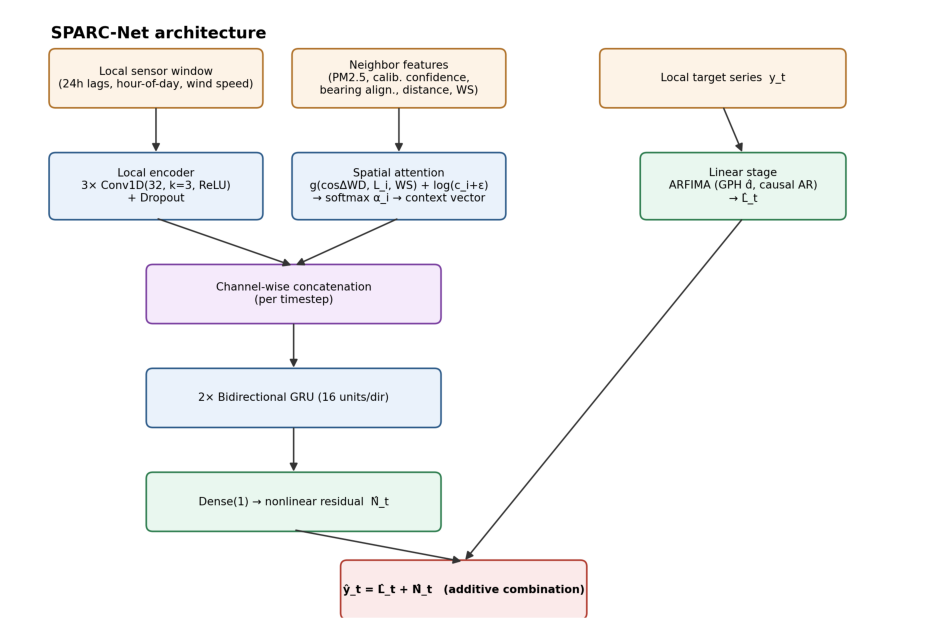

In [14]:
import subprocess
subprocess.run([sys.executable, os.path.join('..', 'scripts', 'make_diagram.py')], check=True)

from PIL import Image
img = Image.open(os.path.join('..', 'figures', 'architecture_diagram.png'))
plt.figure(figsize=(12, 8)); plt.imshow(img); plt.axis('off'); plt.show()


## Summary

This notebook reproduces every quantitative result in the paper: the main ablation ladder
(Table 1), interval-forecasting calibration (Table 2), the coupling-strength sensitivity sweep
(Table 3), the latency benchmark (Table 4), and the real-data validation on the Beijing
Multi-Site Air-Quality Data Set (Table 5), along with all statistical significance tests. See the
`scripts/` directory for the exact, resumable, seed-by-seed scripts used to generate the
`results/*.json` files loaded above.
